<a href="https://colab.research.google.com/github/KarthikSwamy129/LungCancerSurvivalPrediction/blob/main/LungCancerSurvival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas seaborn scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv('/content/dataset_med.csv')
df.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


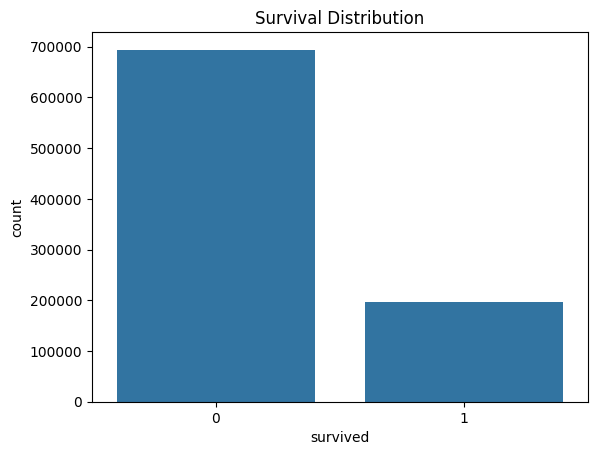

In [4]:
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

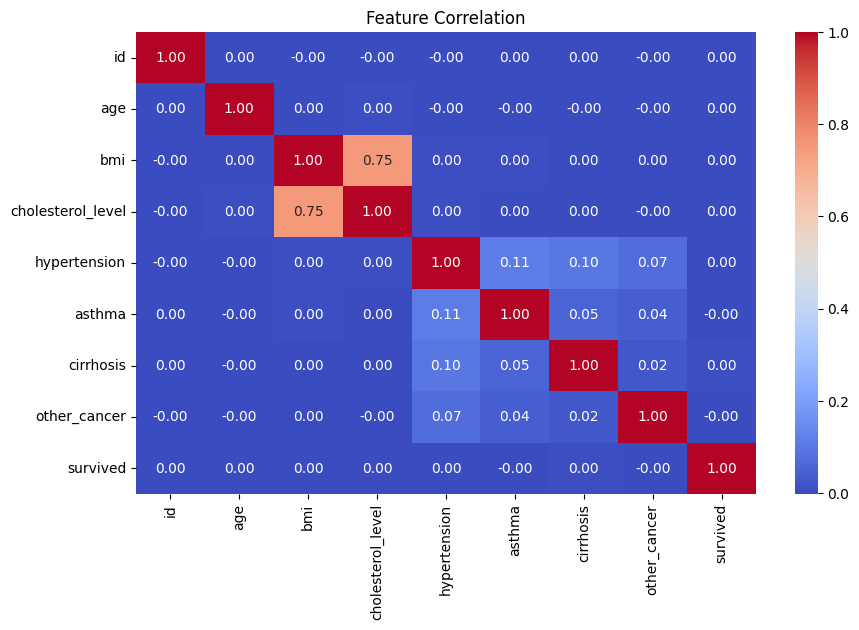

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'country', 'cancer_stage', 'family_history', 'smoking_status', 'treatment_type']
df[categorical_cols] = df[categorical_cols].apply(LabelEncoder().fit_transform)

In [7]:
X = df.drop(['id', 'diagnosis_date', 'end_treatment_date', 'survived'], axis=1)
y = df['survived']

In [8]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [11]:
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

In [12]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6539540848490089

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.68      0.66    138614
           1       0.66      0.63      0.65    138985

    accuracy                           0.65    277599
   macro avg       0.65      0.65      0.65    277599
weighted avg       0.65      0.65      0.65    277599


Confusion Matrix:
 [[93715 44899]
 [51163 87822]]


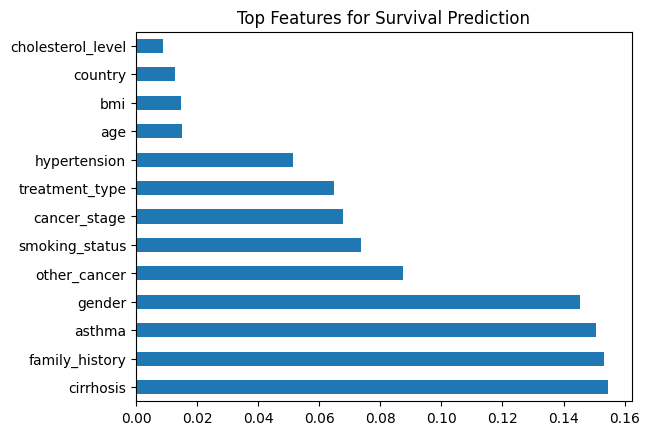

In [13]:
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_importance.plot(kind='barh')
plt.title("Top Features for Survival Prediction")
plt.show()

In [14]:
import joblib
joblib.dump(model, 'lung_cancer_survival_model.pkl')

['lung_cancer_survival_model.pkl']

In [16]:
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model = joblib.load('lung_cancer_survival_model.pkl')

# --- Input section ---
print("Enter patient details:")
id_in      = int(input("ID: "))
age_in     = int(input("Age: "))
gender_in  = input("Gender (Male/Female): ").strip().capitalize()
country_in = input("Country (e.g., Sweden): ").strip().capitalize()
stage_in   = input("Cancer stage (Stage I/II/III/IV): ").strip().capitalize()
fam_hist   = input("Family history of cancer (Yes/No): ").strip().capitalize()
smoke_in   = input("Smoking status (Never Smoked/Current Smoker/Former Smoker/Passive Smoker): ").strip().capitalize()
bmi_in     = float(input("BMI: "))
chol_in    = int(input("Cholesterol level: "))
hyper_in   = int(input("Hypertension (1=Yes, 0=No): "))
asthma_in  = int(input("Asthma (1=Yes, 0=No): "))
cirr_in    = int(input("Cirrhosis (1=Yes, 0=No): "))
other_in   = int(input("Other cancer (1=Yes, 0=No): "))
treat_in   = input("Treatment type (Surgery/Chemotherapy/Radiation/Combined): ").strip().capitalize()

# --- Build dataframe (same columns as training) ---
input_df = pd.DataFrame([{
    'age': age_in,
    'gender': gender_in,
    'country': country_in,
    'cancer_stage': stage_in,
    'family_history': fam_hist,
    'smoking_status': smoke_in,
    'bmi': bmi_in,
    'cholesterol_level': chol_in,
    'hypertension': hyper_in,
    'asthma': asthma_in,
    'cirrhosis': cirr_in,
    'other_cancer': other_in,
    'treatment_type': treat_in
}])

# --- Encode categoricals (same way as training) ---
cat_cols = ['gender', 'country', 'cancer_stage', 'family_history', 'smoking_status', 'treatment_type']
for col in cat_cols:
    le = LabelEncoder()
    # Fit on the *original* training column (you must save these encoders in real projects)
    # Quick hack: fit on current input only (works for demo)
    input_df[col] = LabelEncoder().fit_transform(input_df[col])

# --- Predict ---
pred = model.predict(input_df)[0]
prob = model.predict_proba(input_df)[0][1]

print("\n--- Prediction ---")
print(f"Patient ID {id_in}: {'Will Survive' if pred == 1 else 'Will NOT SURVIVE'} (confidence {prob:.2%})")

Enter patient details:
ID: 45
Age: 28
Gender (Male/Female): Male
Country (e.g., Sweden): Sweden
Cancer stage (Stage I/II/III/IV): III
Family history of cancer (Yes/No): No
Smoking status (Never Smoked/Current Smoker/Former Smoker/Passive Smoker): Current Smoker
BMI: 23
Cholesterol level: 34
Hypertension (1=Yes, 0=No): 1
Asthma (1=Yes, 0=No): 1
Cirrhosis (1=Yes, 0=No): 1
Other cancer (1=Yes, 0=No): 1
Treatment type (Surgery/Chemotherapy/Radiation/Combined): Combined

--- Prediction ---
Patient ID 45: Will NOT SURVIVE (confidence 29.64%)
